# Visualization of the pattern distribution across all the cell types

In [1]:
import pandas as pd
df = pd.read_csv("/scratch/project_465001027/Spatialformer/downstream/subcellular_localization_prediction/data/transcripts.csv")

In [6]:
#  Set the font size globally by doubling the default values
from matplotlib import rcParams
base_font_size = 7  # Assume base font size; you can adjust this based on your normal usage
rcParams.update({
    'font.size': base_font_size * 2,
    'axes.titlesize': base_font_size * 2,
    'axes.labelsize': base_font_size * 2,
    'xtick.labelsize': base_font_size * 2,
    'ytick.labelsize': base_font_size * 2,
    'legend.fontsize': base_font_size * 2,
    'figure.titlesize': base_font_size * 2
})

<Figure size 1800x1800 with 0 Axes>

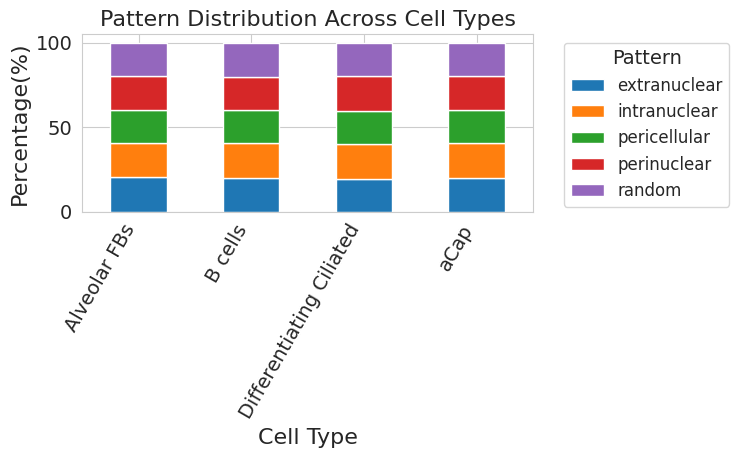

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Count the occurrences of each pattern for each cell type
pattern_counts = df.groupby(['cell_type', 'pattern']).size().unstack(fill_value=0)

# Calculate the percentage
pattern_percentages = pattern_counts.div(pattern_counts.sum(axis=1), axis=0) * 100

# Set the style
sns.set_style("whitegrid")

# Create the stacked bar plot
plt.figure(figsize=(18, 18))  # Increased width to accommodate legend
pattern_percentages.plot(kind='bar', stacked=True)

plt.title('Pattern Distribution Across Cell Types', fontsize=16)
plt.xlabel('Cell Type', fontsize=16)
plt.ylabel('Percentage(%)', fontsize=16)

# Rotate x-axis labels by 60 degrees
plt.xticks(rotation=60, ha='right')

# Move legend outside the plot on the right
plt.legend(title='Pattern', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)

# Adjust layout to prevent cutting off labels
plt.tight_layout()

# Add percentage labels on the bars
# for c in pattern_percentages.columns:
#     pattern_percentages[c].plot(ax=plt.gca(), linewidth=0)
#     plt.gca().bar_label(plt.gca().containers[-1], 
#                         labels=[f'{v:.1f}%' if v >= 5 else '' for v in pattern_percentages[c]], 
#                         label_type='center')

# Add more space on the right for the legend
plt.subplots_adjust(right=0.85)
plt.savefig("/scratch/project_465001027/Spatialformer/downstream/subcellular_localization_prediction/Figures/patterns_density.png", dpi=300, bbox_inches='tight')

plt.show()


In [12]:
pattern_counts

pattern,extranuclear,intranuclear,pericellular,perinuclear,random
cell_type,,,,,
Alveolar FBs,35641,35487,34557,35233,34760
B cells,19951,20381,19668,19866,19975
Differentiating Ciliated,9830,10457,10025,10247,10111
aCap,28163,28529,27674,28122,27443
